First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Missing values after replacing invalid zeros:
Pregnancies       

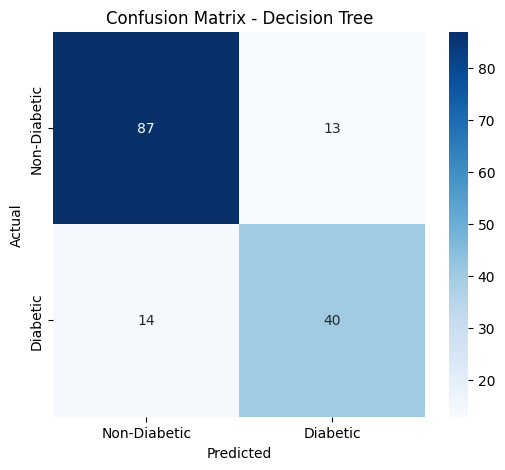

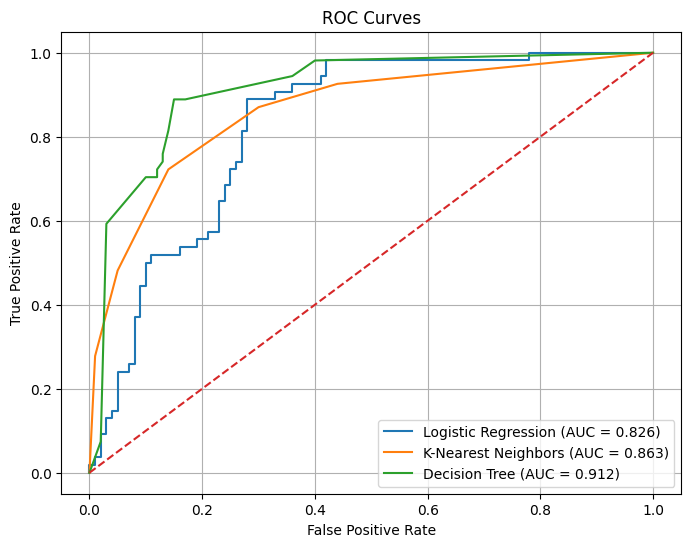

In [2]:
 # ============================================================
# PIMA INDIANS DIABETES DATASET
# Supervised Classification
# ============================================================

# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# ============================================================
# 2. Load Dataset
# ============================================================

# If using Google Colab, upload the CSV file first.
# Change the filename if your file has a different name.

df = pd.read_csv("diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ============================================================
# 3. Separate Features and Target
# ============================================================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

# ============================================================
# 4. Handle Invalid Values
# ============================================================

# In the Pima dataset, zero is not medically valid for
# some features, so replace zero with NaN.

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = X[invalid_columns].replace(0, np.nan)

print("\nMissing values after replacing invalid zeros:")
print(X.isnull().sum())

# Fill missing values using median
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("\nMissing values after imputation:")
print(X_imputed.isnull().sum())

# ============================================================
# 5. Stratified Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# ============================================================
# 6. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 7. Create Classification Models
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    )
}

# ============================================================
# 8. Train Models and Evaluate
# ============================================================

results = []

for name, model in models.items():

    # Logistic Regression and KNN require scaled data.
    # Decision Tree does not require scaling.
    if name == "Decision Tree":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    # --------------------------------------------------------
    # Display Results
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-Diabetic", "Diabetic"],
        zero_division=0
    ))

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))

    # Extract TN, FP, FN, TP
    TN, FP, FN, TP = cm.ravel()

    print("\nTrue Negative (TN):", TN)
    print("False Positive (FP):", FP)
    print("False Negative (FN):", FN)
    print("True Positive (TP):", TP)

# ============================================================
# 9. Compare All Models
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

print("\n\nMODEL COMPARISON")
print("=" * 80)
print(results_df.round(4))

# ============================================================
# 10. Find Best Model
# ============================================================

best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("\nBest Model based on F1-Score:")
print(best_model["Model"])

# ============================================================
# 11. Plot Confusion Matrix for Best Model
# ============================================================

best_model_name = best_model["Model"]
best_model_object = models[best_model_name]

if best_model_name == "Decision Tree":
    best_predictions = best_model_object.predict(X_test)
else:
    best_predictions = best_model_object.predict(X_test_scaled)

best_cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - " + best_model_name)
plt.show()

# ============================================================
# 12. ROC Curves for All Models
# ============================================================

plt.figure(figsize=(8, 6))

for name, model in models.items():

    if name == "Decision Tree":
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()